In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# <h4> Customer Analytics: RFM and Cohort Retention

<font size="4"> Load data

In [2]:
sales = pd.read_csv('../Data/Processed/sales.csv')
customers = pd.read_csv("../Data/Raw/olist_customers_dataset.csv")
date_columns = ['order_purchase_timestamp',
                'order_approved_at',
                'order_delivered_carrier_date',
                'order_delivered_customer_date',
                'order_estimated_delivery_date'
                ]

for col in date_columns:
    sales[col] =pd.to_datetime(sales[col])

<font size="4"> RFM Analysis <br>
<font size="2">EFM segmentation evaluates customer behavior using three dimensions:

- **Recency** how recently a customer made a purchase 
- **Frequency** how often a customer purchases
- **Monetary** how much revenue a customer generates

This framework helkps identify high-value and low-engagement customer groups.

<font size="4"> Build RFM table

In [3]:
snapshot_date = sales['order_purchase_timestamp'].max()   

rfm = sales.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'total_revenue': 'sum'
})
rfm.columns = ['recency', 'frequency', 'monetary']
rfm.describe()

,recency,frequency,monetary
count,96478.000000,96478.0,96478.000000
mean,239.121364,1.0,159.826839
std,152.836972,0.0,218.794219
min,0.000000,1.0,9.590000
25%,115.000000,1.0,61.850000
50%,220.000000,1.0,105.280000
75%,349.000000,1.0,176.260000
max,713.000000,1.0,13664.080000


<font size="4">Assign RFM scores <br>
<font size="2">This step converts recency, frequency and monetary values into relative score using quiniles, makin customer comparation easier.

In [16]:
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])      # Scores RFM (quintiles)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4 ,5])

In [17]:
rfm['rfm_score']=(
    rfm['r_score'].astype(str)+
    rfm['f_score'].astype(str)+
    rfm['m_score'].astype(str)
)

<font size="2"> Conclusion: Scoring standardizes customer behavior into comparable groups, wich simplifies segmentation and interpretation.

In [7]:
rfm.sort_values('monetary', ascending=False).head(10)

,recency,frequency,monetary,r_score,f_Score,m_score,rfm_score
customer_id,,,,,,,
1617b1357756262bfa56ab541c47bc16,333,1,13664.08,2,1,5,215
ec5b2ba62e574342386871631fafd3fc,45,1,7274.88,5,5,5,555
c6e2731c5b391845f6800c97401a43a9,562,1,6929.31,1,4,5,145
f48d464a0baaea338cb25f816991ab1f,34,1,6922.21,5,5,5,555
3fd6777bbce08a352fddd04e4a7cc8f6,461,1,6726.66,1,2,5,125
05455dfa7cd02f13d132aa7a6a9729c6,278,1,6081.54,2,1,5,215
df55c14d1476a9a3467f131269c2477f,514,1,4950.34,1,5,5,155
24bbf5fd2f2e1b359ee7de94defc4a15,497,1,4764.34,1,1,5,115
3d979689f636322c62418b6346b1c6d2,68,1,4681.78,5,2,5,525


<font size="4">Average RFM metrics <br>
<font size="2">This section reports the average recency, frequency and monetary values across customers.

In [8]:
print(f"Recency promedio: {rfm['recency'].mean():.3%}")
print(f"Frequency promedio: {rfm['frequency'].mean():.3%}")
print(f"Monetary promedio: {rfm['monetary'].mean():.3%}")

Recency promedio: 23912.136%
Frequency promedio: 100.000%
Monetary promedio: 15982.684%


<font size="4"> RFM insight <br>
<font size="2">The average frequency is close to 1, which suggests that most customers made only one purchase during the observed period. This indicates low repeat purchasing behavior and limited customer retention. In other words, the marketplace appears to rely more on customer acquisition than on frequent repurchasing.

<h5> Cohort retention analysis <br>
<font size="2"> Cohort analysis measures how many customers return to make additional purchases after their first order. By grouping customers according to the month of their first purchase, it becomes possible to observe retention patterns over time.

<font size="4"> Build customer-cohort dataset

In [9]:
sales_customers = sales.merge(
    customers,
    on="customer_id",
    how="left"
)

<font size="4"> Define purchase month and cohort manth <br>
<font size="2">This step assigns each order to a purchase month and identifies the first purchase month for each customer.

In [11]:
sales_customers['order_month'] = sales_customers['order_purchase_timestamp'].dt.to_period('M')

first_purchase = sales_customers.groupby('customer_unique_id')['order_month'].min()  ## Mes de priemra compra del cliente
sales_customers['cohort_month'] = sales_customers['customer_unique_id'].map(first_purchase)

<font size="4">Calculate cohort index <br>
<font size="2">The cohort index measures how many months hace passed since each customer's first purchase.

In [12]:

sales_customers['cohort_index'] = (
    (sales_customers['order_month']-sales_customers['cohort_month'])
    ).apply(lambda x:x.n)

<font size="4">Build cohort table<br>
<font size="2">This step counts how many unique customers remain active in each cohort and time period.

In [13]:

cohort_data = sales_customers.groupby(
    ['cohort_month', 'cohort_index']
).agg(
    customer=('customer_unique_id', 'nunique')
).reset_index()

<font size="4">Reshape cohort data <br>
<font size="2">This step transforms the cohort data into matrix format for retention analysis.

In [14]:

cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer'
)

<font size="4">Retention heatmap <br>
<font size="2">The following heatmap visualizes customers retention across cohorts and months after acquisitions.

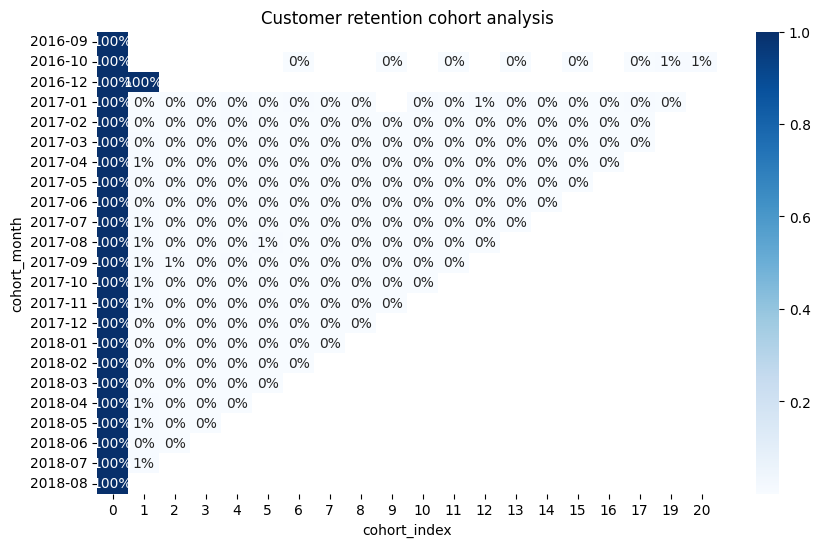

In [15]:
cohort_retention = cohort_table.divide(
    cohort_table.iloc[:,0],
    axis=0
)
plt.figure(figsize=(10,6))

sns.heatmap(
    cohort_retention,
    annot=True,
    fmt='.0%',
    cmap='Blues'
)
plt.title('Customer retention cohort analysis')
plt.show()

<font size="4">Final conclusions

<font size="2">

- RFM analysis shows that most customers purchase only once, with limited repeat transaction behavior.
- A small subset of customers contributes a disproportionately large share of revenue.
- Cohort retention is low across most acquisition periods, confirming weak repurchase dynamics.
- These results suggest that customer retention is a major opportunity area for the business.

Overall, the customer base appears broad but not highly loyal, which makes retention strategies especially relevant.